In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow
from IPython.display import HTML, display

Because the notebook is inside notebooks/, the dataset is one directory above it:

In [2]:
print(pyarrow.__version__)

24.0.0


In [3]:
df = pd.read_csv(
    '../data/raw/Student_Performance.csv',
    engine='pyarrow',
    dtype_backend='pyarrow'
    )

In [4]:
df.head(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype          
---  ------                            --------------  -----          
 0   Hours Studied                     10000 non-null  int64[pyarrow] 
 1   Previous Scores                   10000 non-null  int64[pyarrow] 
 2   Extracurricular Activities        10000 non-null  string[pyarrow]
 3   Sleep Hours                       10000 non-null  int64[pyarrow] 
 4   Sample Question Papers Practiced  10000 non-null  int64[pyarrow] 
 5   Performance Index                 10000 non-null  double[pyarrow]
dtypes: double[pyarrow](1), int64[pyarrow](4), string[pyarrow](1)
memory usage: 454.2 KB


In [6]:
df.shape

(10000, 6)

In [7]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.9929,69.4457,6.5306,4.5833,55.2248
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.0,40.0,4.0,0.0,10.0
25%,3.0,54.0,5.0,2.0,40.0
50%,5.0,69.0,7.0,5.0,55.0
75%,7.0,85.0,8.0,7.0,71.0
max,9.0,99.0,9.0,9.0,100.0


When mean and median are close, that's an early hint that these distributions may not be extremely skewed. But don't conclude “normal distribution” from this alone. We need plots later.

In [8]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [9]:
df["Extracurricular Activities"].value_counts()

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64[pyarrow]

In [10]:
df["Extracurricular Activities"].unique()

<ArrowExtensionArray>
['Yes', 'No']
Length: 2, dtype: string[pyarrow]

In [11]:
df.duplicated().sum()

np.int64(127)

In [12]:
duplicate_rows = (
    df[df.duplicated(keep=False)]
    .sort_values(by=list(df.columns))
)

duplicate_rows

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
6975,1,41,No,7,3,12.0
9966,1,41,No,7,3,12.0
2225,1,42,Yes,9,7,17.0
4986,1,42,Yes,9,7,17.0
2647,1,57,No,8,0,31.0
...,...,...,...,...,...,...
8118,9,86,Yes,6,9,83.0
3482,9,87,No,7,3,88.0
4261,9,87,No,7,3,88.0
8214,9,87,No,7,9,86.0


In [13]:
display(
    HTML(
        f"""
        <div style="height: 400px; overflow-y: scroll;">
            {duplicate_rows.to_html()}
        </div>
        """
    )
)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
6975,1,41,No,7,3,12.0
9966,1,41,No,7,3,12.0
2225,1,42,Yes,9,7,17.0
4986,1,42,Yes,9,7,17.0
2647,1,57,No,8,0,31.0
8522,1,57,No,8,0,31.0
3398,1,63,Yes,8,3,37.0
8184,1,63,Yes,8,3,37.0
4573,1,66,No,8,2,40.0
5578,1,66,No,8,2,40.0


In [14]:
duplicate_groups = (
    df.groupby(list(df.columns), dropna=False)
      .size()
      .reset_index(name="count")
      .query("count > 1")
      .sort_values("count", ascending=False)
)

duplicate_groups.head(20)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,count
4740,5,59,Yes,9,0,45.0,3
27,1,41,No,7,3,12.0,2
339,1,57,No,8,0,31.0,2
464,1,63,Yes,8,3,37.0,2
499,1,66,No,8,2,40.0,2
58,1,42,Yes,9,7,17.0,2
615,1,72,Yes,4,1,44.0,2
736,1,79,Yes,7,3,54.0,2
748,1,80,No,6,3,55.0,2
767,1,81,No,6,6,55.0,2


### Duplicate records

Exact duplicate rows were found in the dataset.

However, the dataset has no unique student identifier, and the features are mostly
discrete variables. Therefore, identical rows may reasonably represent different
students with the same recorded characteristics.

Decision: retain duplicate rows.

In [15]:
numeric_cols = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced",
    "Performance Index"
]

df[numeric_cols].nunique()

Hours Studied                        9
Previous Scores                     60
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64

In [16]:
df["Hours Studied"].value_counts().sort_index()

Hours Studied
1    1152
2    1085
3    1119
4    1085
5    1094
6    1133
7    1129
8    1088
9    1115
Name: count, dtype: int64[pyarrow]

In [17]:
df["Sleep Hours"].value_counts().sort_index()

Sleep Hours
4    1619
5    1606
6    1673
7    1676
8    1804
9    1622
Name: count, dtype: int64[pyarrow]

In [18]:
df["Sample Question Papers Practiced"].value_counts().sort_index()

Sample Question Papers Practiced
0     951
1     978
2     930
3    1035
4     955
5    1028
6    1059
7     987
8    1026
9    1051
Name: count, dtype: int64[pyarrow]

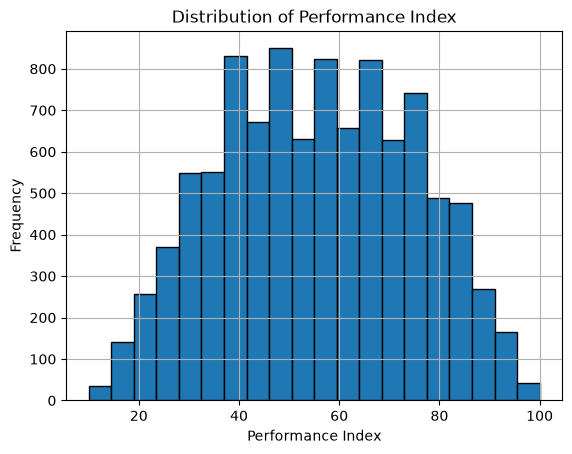

In [19]:
df["Performance Index"].hist(
    bins=20,
    edgecolor="black"
)

plt.xlabel("Performance Index")
plt.ylabel("Frequency")
plt.title("Distribution of Performance Index")
plt.show()

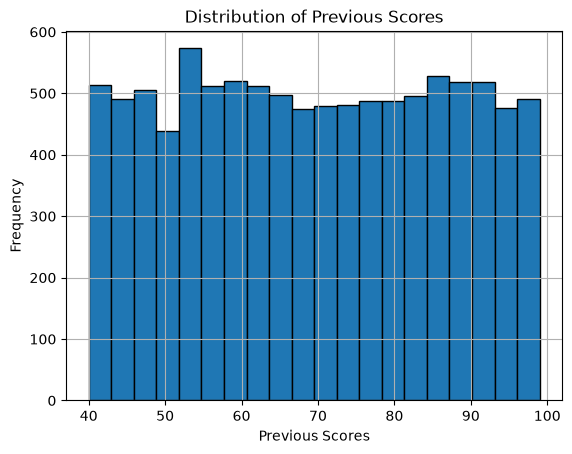

In [20]:
df["Previous Scores"].hist(
    bins=20,
    edgecolor="black"
)

plt.xlabel("Previous Scores")
plt.ylabel("Frequency")
plt.title("Distribution of Previous Scores")
plt.show()

In [21]:
# Create a temporary DataFrame for correlation analysis
corr_df = df.copy()

# Temporary encoding ONLY for EDA
corr_df["Extracurricular Activities"] = (
    corr_df["Extracurricular Activities"]
    .map({"No": 0, "Yes": 1})
)

# Correlation of every predictor with the target
target_corr = (
    corr_df.corr(numeric_only=True)["Performance Index"]
    .drop("Performance Index")
    .sort_values()
)

target_corr

Extracurricular Activities          0.024525
Sample Question Papers Practiced    0.043268
Sleep Hours                         0.048106
Hours Studied                       0.373730
Previous Scores                     0.915189
Name: Performance Index, dtype: float64

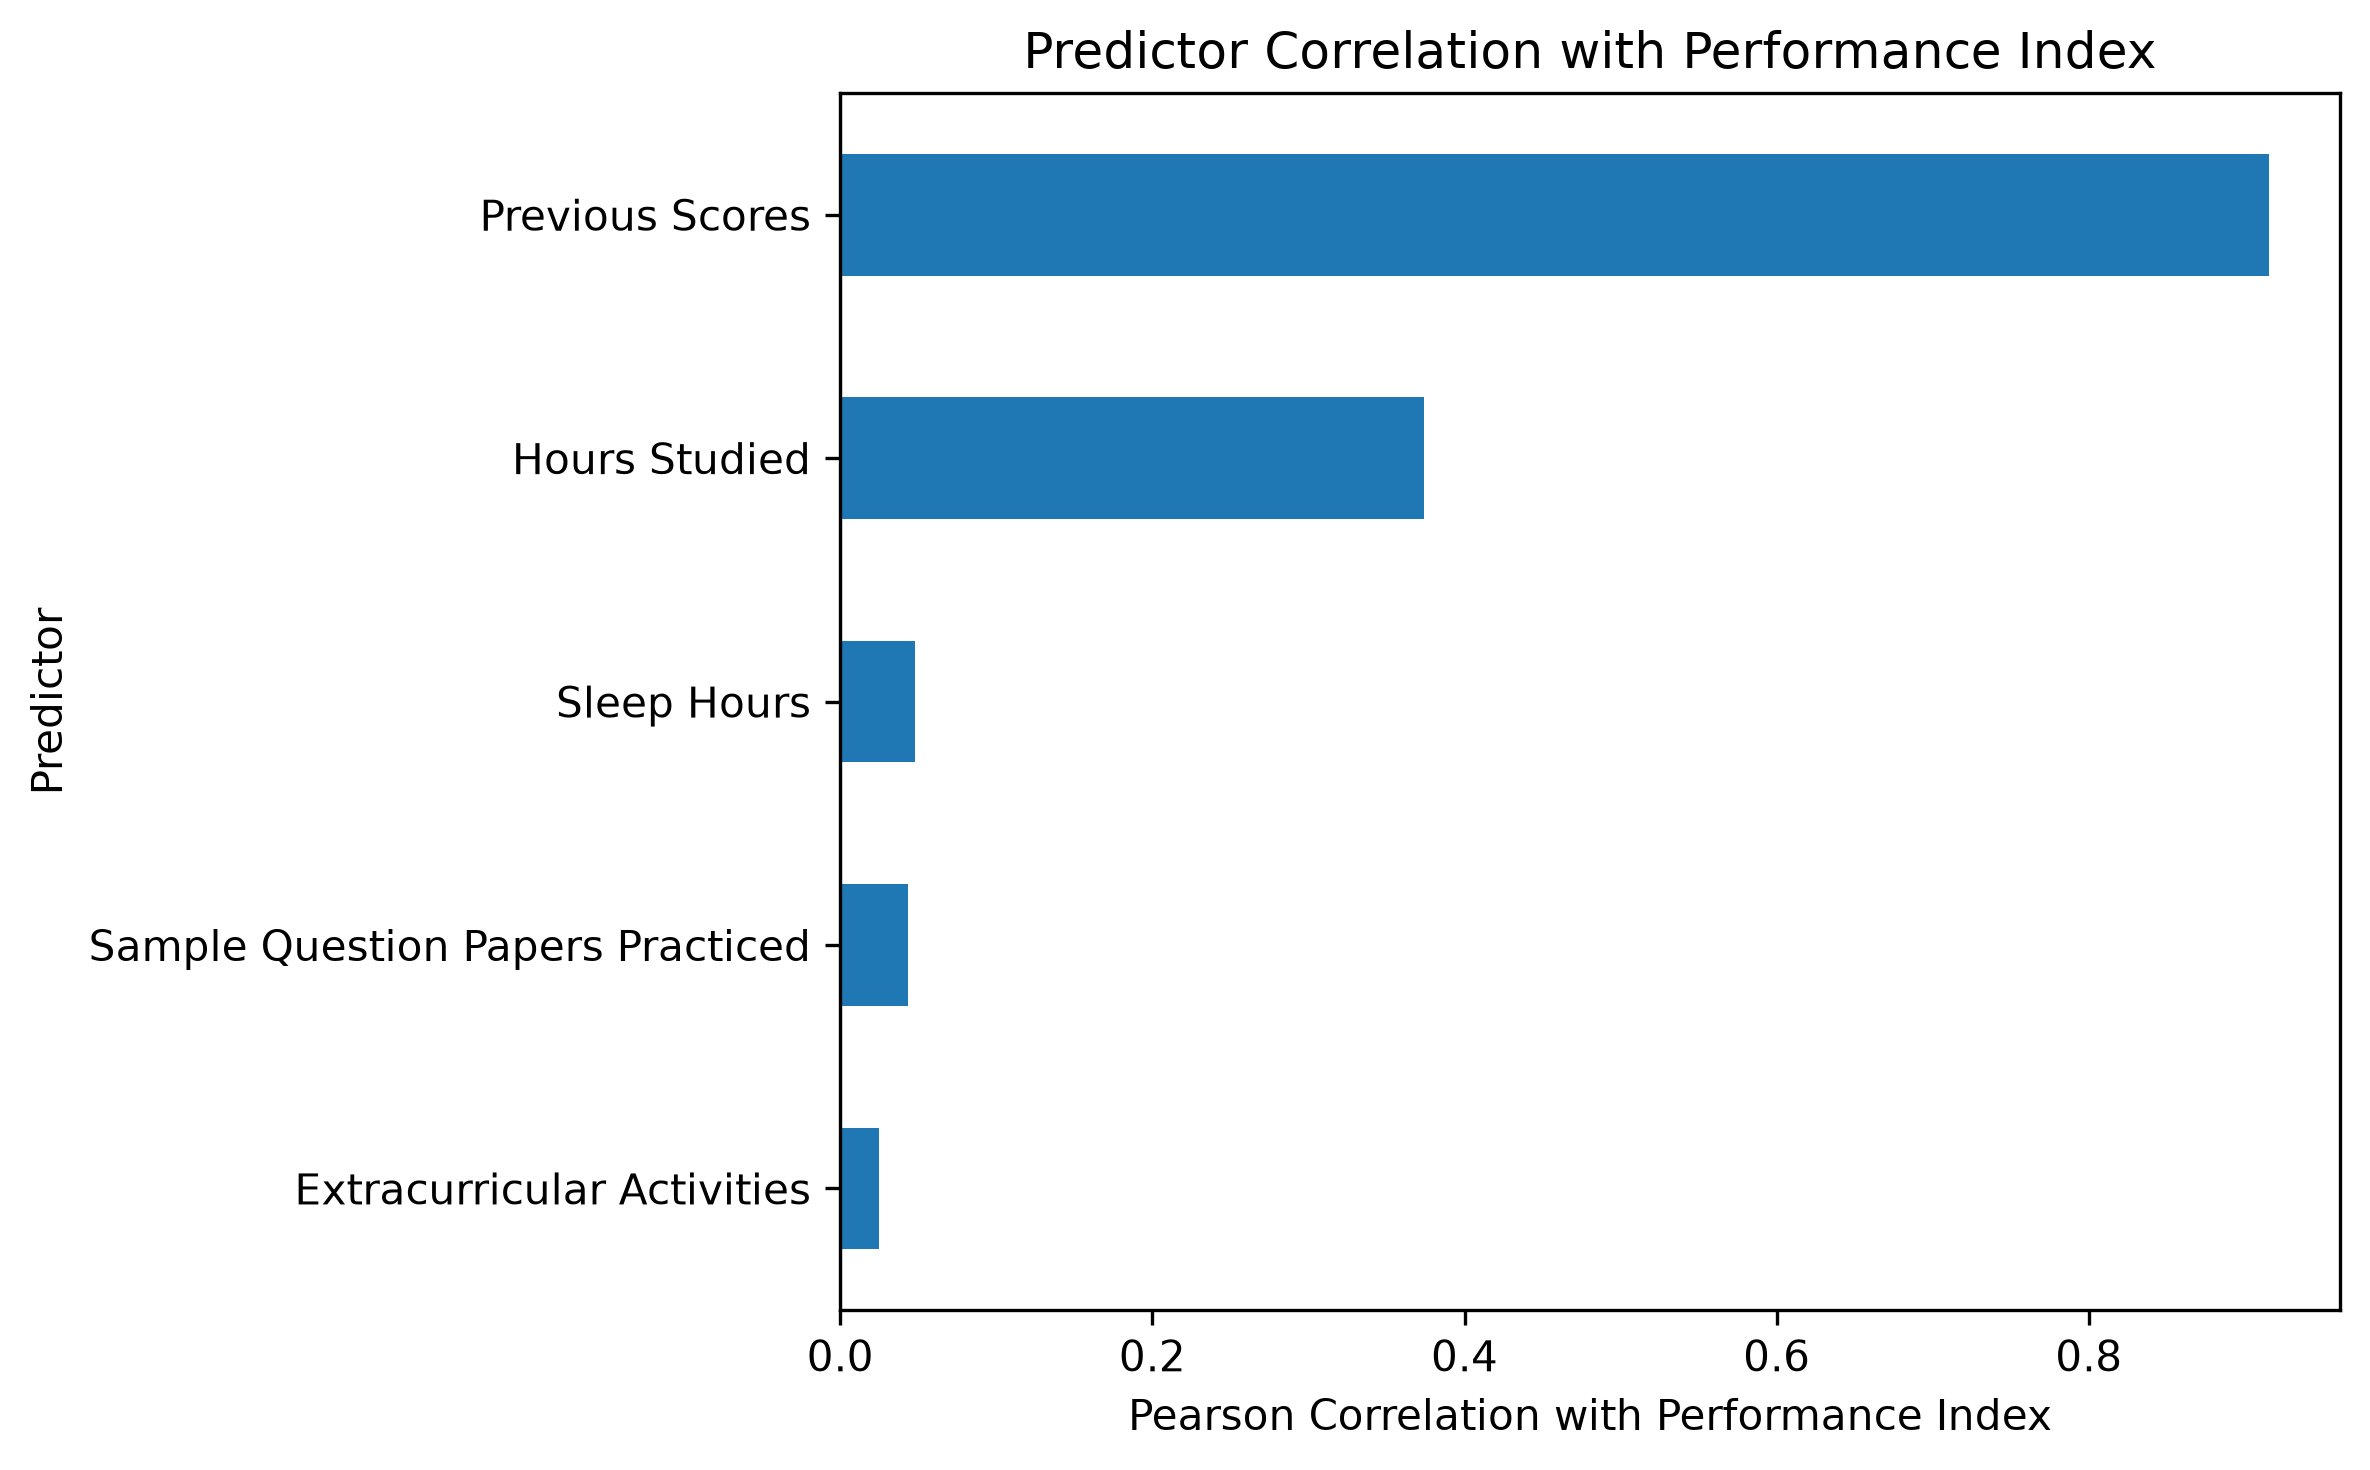

In [22]:
plt.figure(figsize=(8, 5), dpi=300)

target_corr.plot(kind="barh")

plt.xlabel("Pearson Correlation with Performance Index")
plt.ylabel("Predictor")
plt.title("Predictor Correlation with Performance Index")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

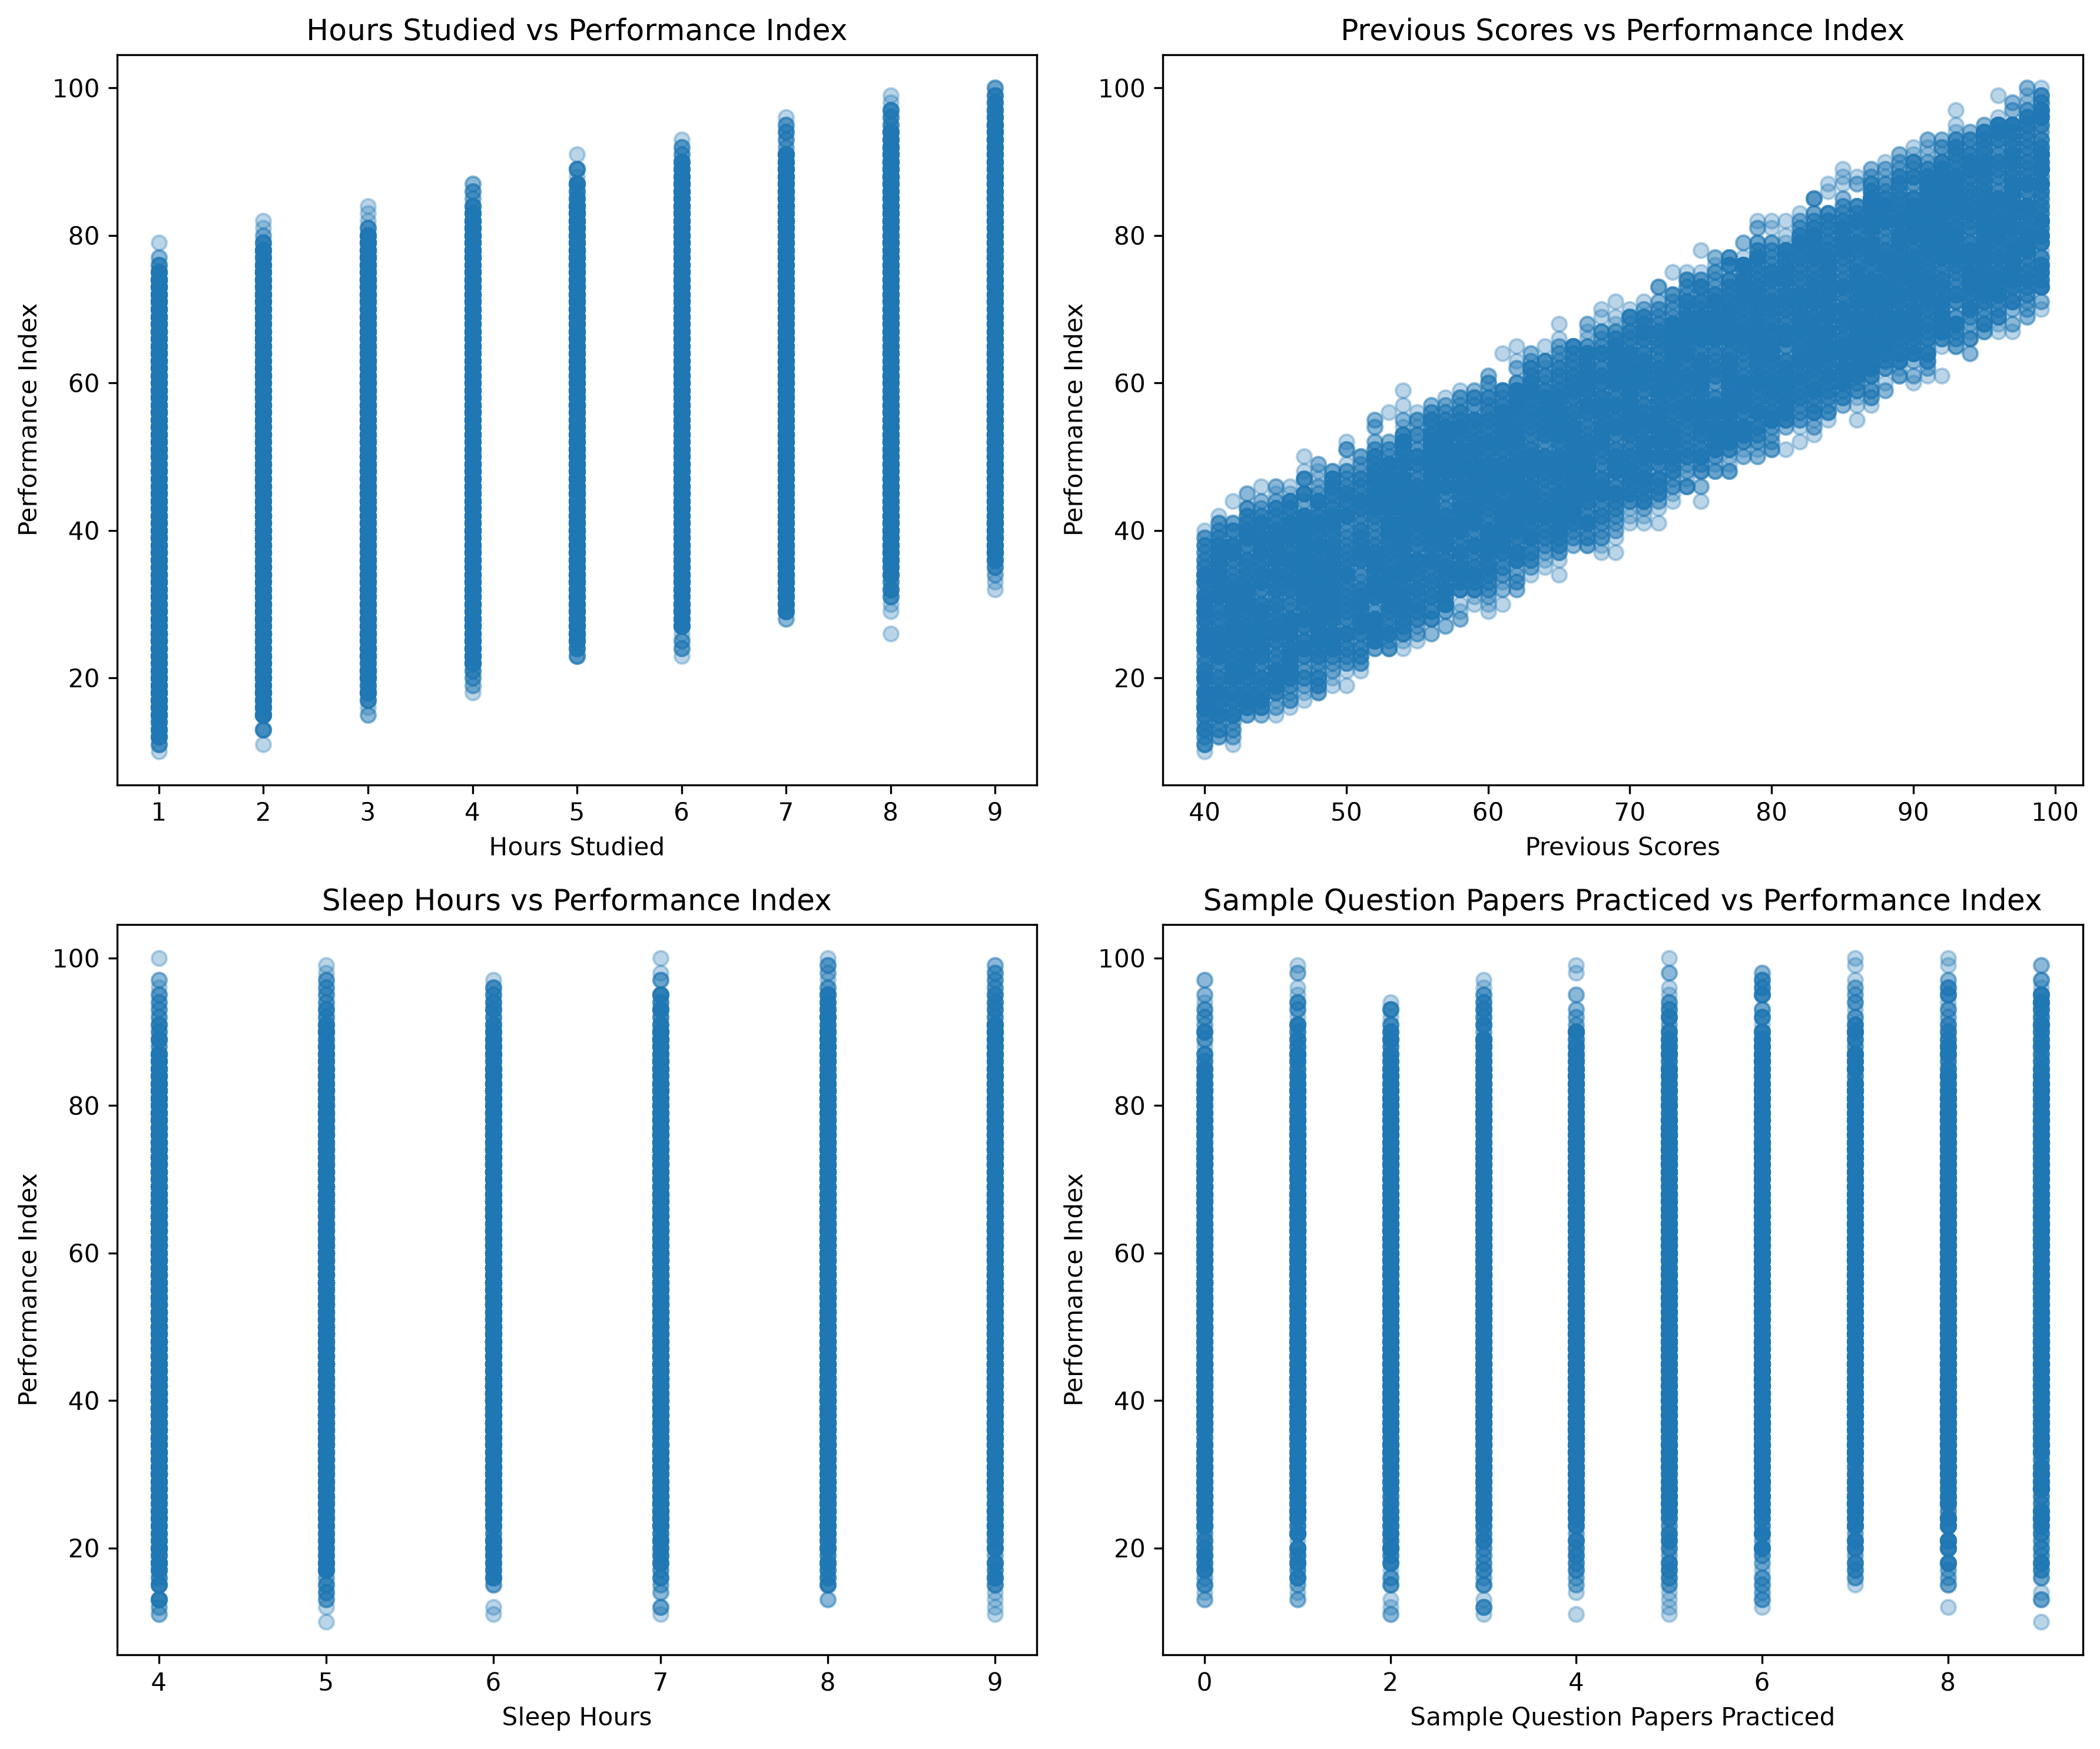

In [23]:
numeric_predictors = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

target = "Performance Index"

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
axes = axes.ravel()

for i, col in enumerate(numeric_predictors):
    axes[i].scatter(df[col], df[target], alpha=0.3)
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

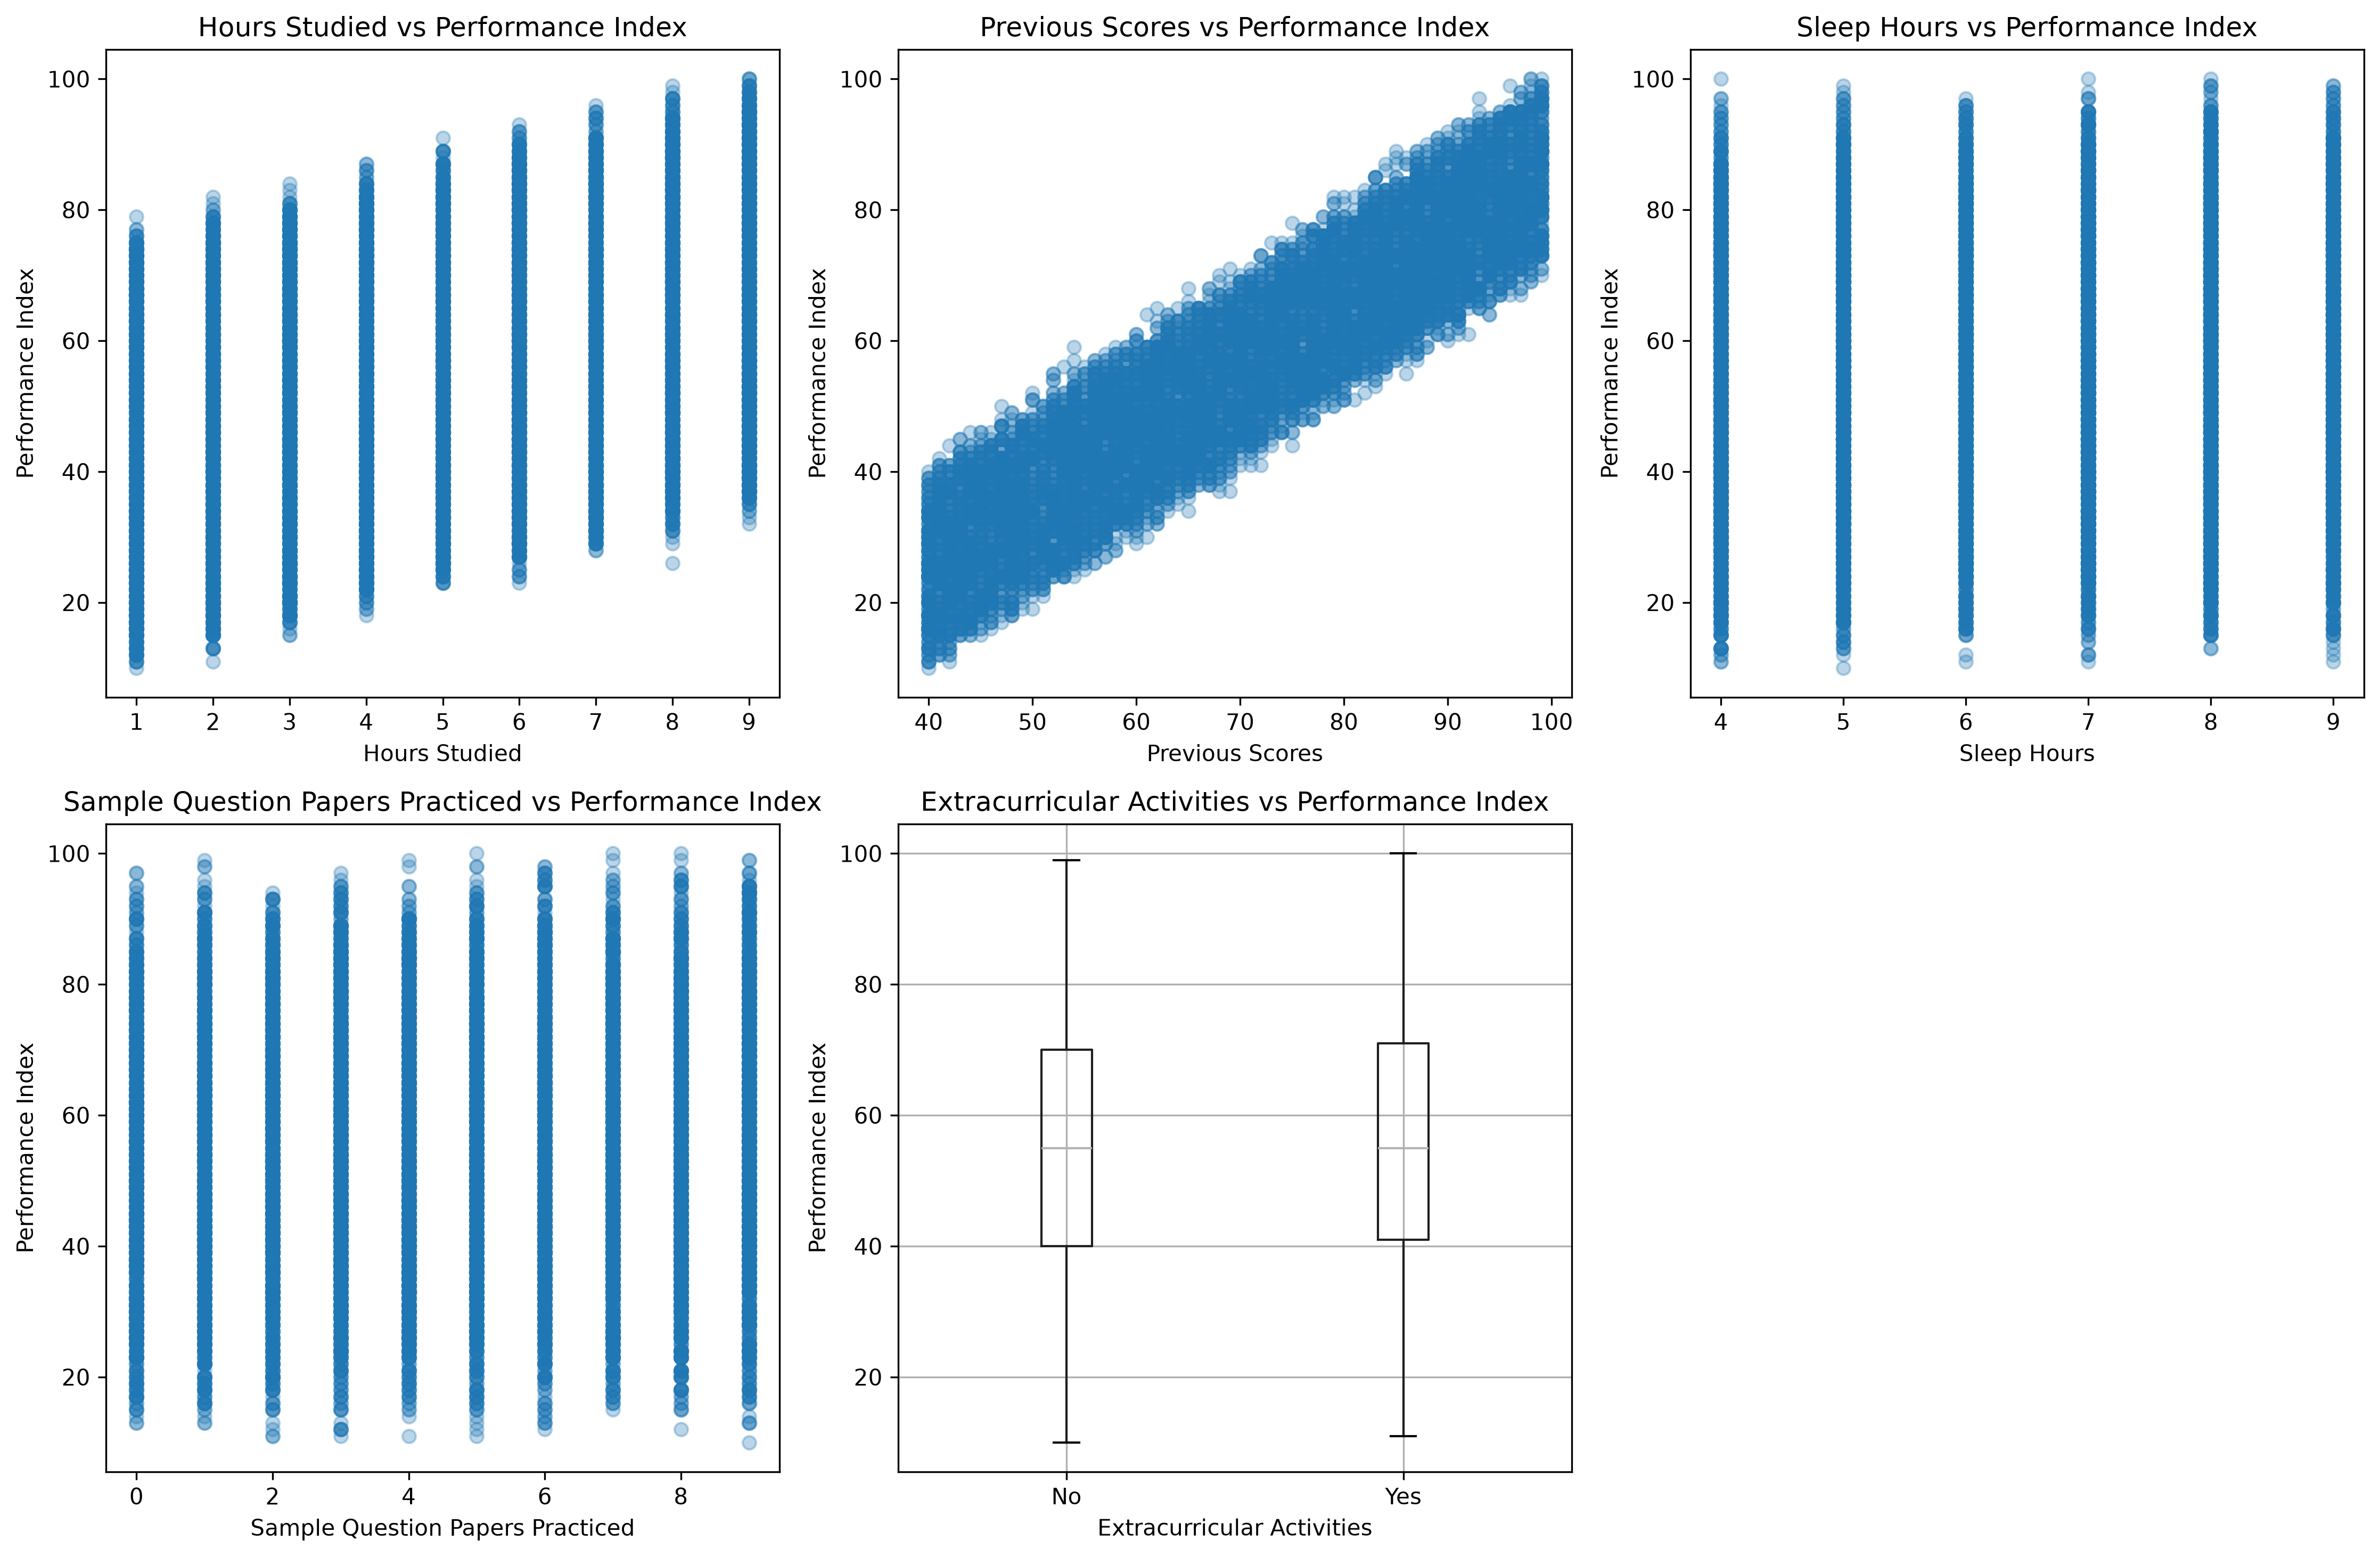

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=300)
axes = axes.ravel()

numeric_predictors = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

target = "Performance Index"

# 4 scatter plots
for i, col in enumerate(numeric_predictors):
    axes[i].scatter(df[col], df[target], alpha=0.3)
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

# boxplot for categorical predictor
df.boxplot(column=target, by="Extracurricular Activities", ax=axes[4])
axes[4].set_title("Extracurricular Activities vs Performance Index")
axes[4].set_xlabel("Extracurricular Activities")
axes[4].set_ylabel(target)

# remove automatic pandas subtitle if needed
fig.suptitle("")

# hide unused subplot
axes[5].axis("off")

plt.tight_layout()
plt.show()

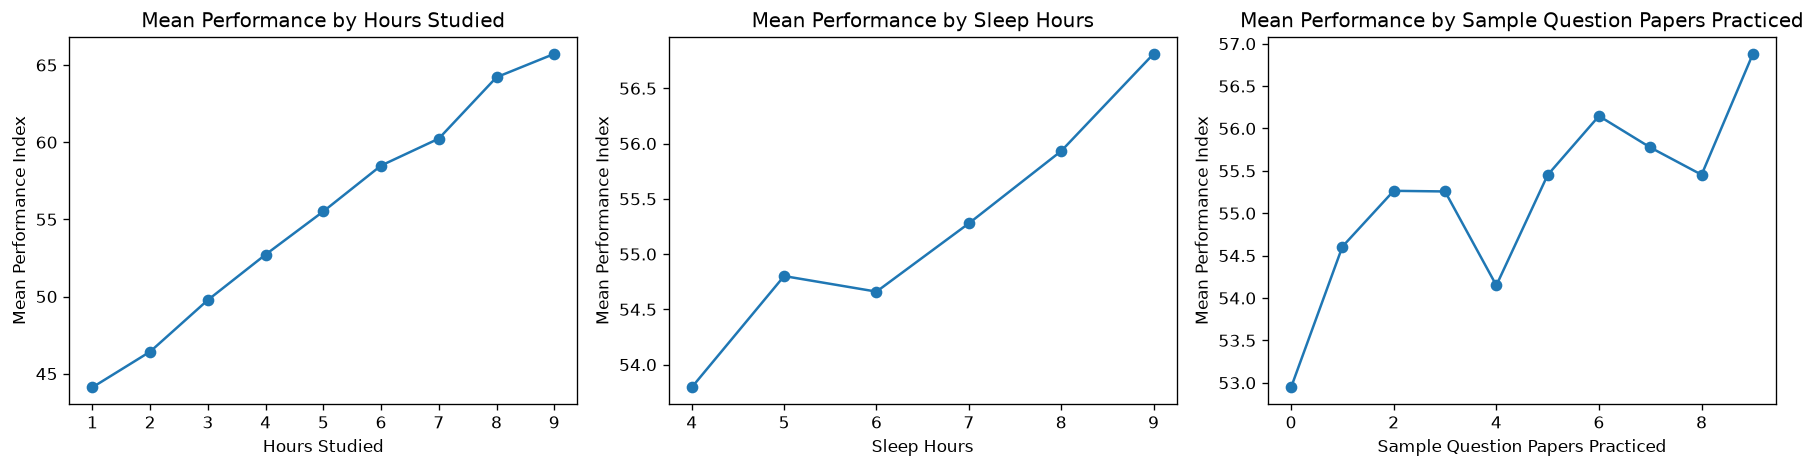

In [25]:
discrete_predictors = [
    "Hours Studied",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    dpi=120
)

for ax, col in zip(axes, discrete_predictors):

    group_mean = (
        df.groupby(col)["Performance Index"]
        .mean()
    )

    ax.plot(
        group_mean.index,
        group_mean.values,
        marker="o"
    )

    ax.set_title(f"Mean Performance by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Mean Performance Index")

plt.tight_layout()
plt.show()

In [26]:
df.groupby("Extracurricular Activities")["Performance Index"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Extracurricular Activities,,,,
No,5052,54.758511,55.0,19.152068
Yes,4948,55.700889,55.0,19.264416


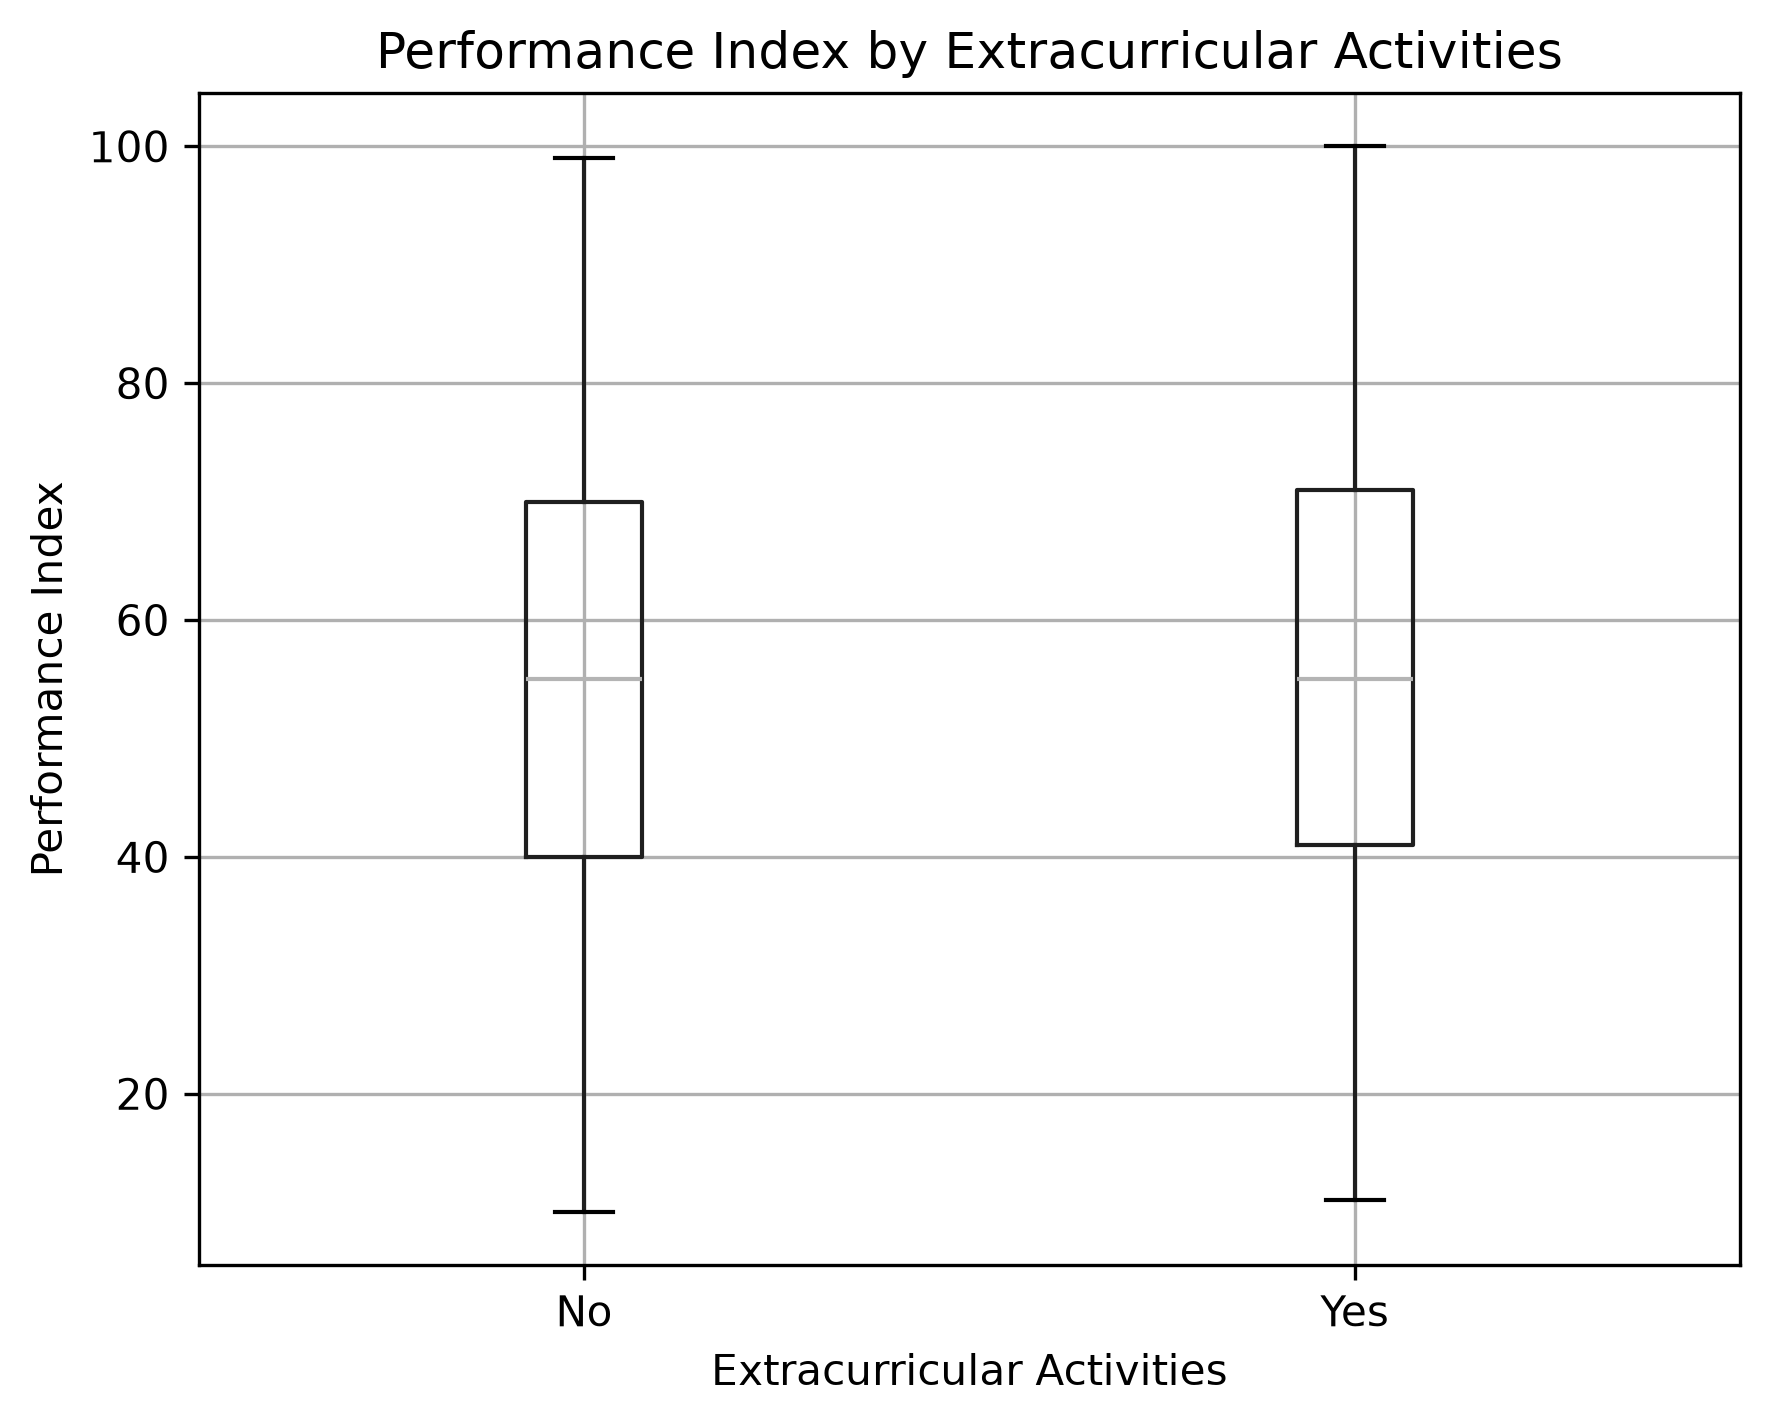

In [27]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

df.boxplot(
    column="Performance Index",
    by="Extracurricular Activities",
    ax=ax
)

ax.set_title("Performance Index by Extracurricular Activities")
fig.suptitle("")
ax.set_xlabel("Extracurricular Activities")
ax.set_ylabel("Performance Index")

plt.tight_layout()
plt.show()

In [28]:
numeric_predictors = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

predictor_corr = df[numeric_predictors].corr()

predictor_corr

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
Hours Studied,1.000000,-0.012390,0.001245,0.017463
Previous Scores,-0.012390,1.000000,0.005944,0.007888
Sleep Hours,0.001245,0.005944,1.000000,0.003990
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000


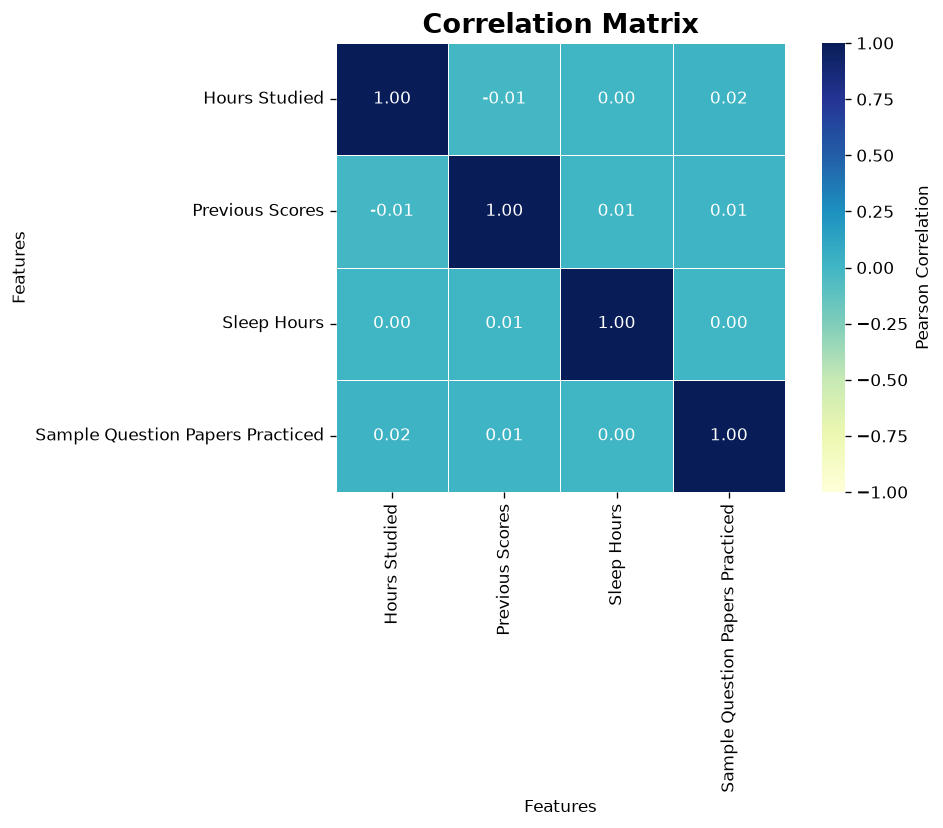

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_predictors = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

predictor_corr = df[numeric_predictors].corr()

plt.figure(figsize=(9, 7), dpi=120)

sns.heatmap(
    predictor_corr,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Correlation Matrix", fontsize=16, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### Correlation among numerical predictors

The numerical predictors show near-zero pairwise Pearson correlations,
with all off-diagonal correlations close to 0.

This suggests there is no obvious pairwise linear multicollinearity among
the numerical predictors.

However, near-zero Pearson correlation does not prove statistical independence
or rule out nonlinear relationships.